In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('/kaggle/input/datasets/adityamaj20051004/dataset1/dataset.csv')

In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [5]:
df.shape

(114000, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [7]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [11]:
df.dropna(subset=['track_name', 'artists'], inplace=True)

In [12]:
df['duration_min'] = df['duration_ms'] / 60000

In [13]:
df[['track_name','artists','popularity']]\
.sort_values(by='popularity', ascending=False)\
.head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
89411,La Bachata,Manuel Turizo,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
88410,La Bachata,Manuel Turizo,98
68303,La Bachata,Manuel Turizo,98


In [14]:
df.groupby('artists')['popularity']\
.mean()\
.sort_values(ascending=False)\
.head(10)

artists
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Harry Styles                    92.0
Rema;Selena Gomez               92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: popularity, dtype: float64

In [15]:
df['track_genre'].value_counts().head(10)

track_genre
acoustic       1000
british        1000
electronic     1000
emo            1000
funk           1000
garage         1000
disco          1000
country        1000
rock           1000
rock-n-roll    1000
Name: count, dtype: int64

In [16]:
df.groupby('track_genre')['popularity']\
.mean()\
.sort_values(ascending=False)\
.head(10)

track_genre
pop-film     59.280280
k-pop        56.963928
chill        53.704705
sad          52.379000
grunge       49.582583
indian       49.528529
anime        48.766767
emo          48.128000
pop          47.903323
sertanejo    47.866000
Name: popularity, dtype: float64

In [17]:
df.groupby('explicit')['popularity'].mean()

explicit
False    33.024896
True     36.524799
Name: popularity, dtype: float64

In [18]:
df.groupby('track_genre')['danceability']\
.mean()\
.sort_values(ascending=False)\
.head(10)

track_genre
kids              0.778630
chicago-house     0.766240
reggaeton         0.758521
latino            0.757396
reggae            0.745331
hip-hop           0.735937
dancehall         0.734082
minimal-techno    0.729316
detroit-techno    0.722466
latin             0.721410
Name: danceability, dtype: float64

In [19]:
df.groupby('track_genre')['energy']\
.mean()\
.sort_values(ascending=False)\
.head(10)

track_genre
death-metal      0.931468
grindcore        0.924323
metalcore        0.914485
happy            0.910901
hardstyle        0.901173
drum-and-bass    0.876380
black-metal      0.874721
heavy-metal      0.874152
party            0.871349
j-idol           0.868593
Name: energy, dtype: float64

In [20]:
df[['track_name','duration_min']]\
.sort_values(by='duration_min', ascending=False)\
.head(10)

,track_name,duration_min
73617,Unity (Voyage Mix) Pt. 1,87.288250
10935,Crossing Wires 002 - Continuous DJ Mix,79.817100
24348,The Lab 03 - Continuous DJ Mix Part 1,78.838367
73840,Amnesia Ibiza Underground 10 DJ Mix,76.064950
13344,House of Om - Mark Farina - Continuous Mix,74.125333
13245,Live In Tokyo - Continuous Mix,72.330433
13195,Greenhouse Construction,72.245350
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",70.770100
101390,Ocean Waves Sounds,68.670967
45063,Internal Flight (Remastered),64.604600


In [21]:
df[['track_name','valence']]\
.sort_values(by='valence', ascending=False)\
.head(10)

,track_name,valence
1813,The Demander,0.995
87943,Flor de Capomo,0.994
46041,Zuipen,0.993
66064,Roll Your Hands,0.993
48741,Zuipen,0.993
25269,Hands Up - Single Version,0.992
66808,I Like Pencils,0.992
36181,Hands Up - Single Version,0.992
32429,Hands Up - Single Version,0.992
24889,GOD Will Provide,0.991


In [22]:
df[df['tempo'] > 120][['track_name','tempo']].head(20)

,track_name,tempo
3,Can't Help Falling In Love,181.740
6,Say Something,141.284
7,I'm Yours,150.960
8,Lucky,130.088
11,I Won't Give Up,133.406
12,Solo,124.234
14,Hold On - Remix,120.004
18,Lucky,130.088
20,I'm Yours,150.960
22,Say Something,141.284


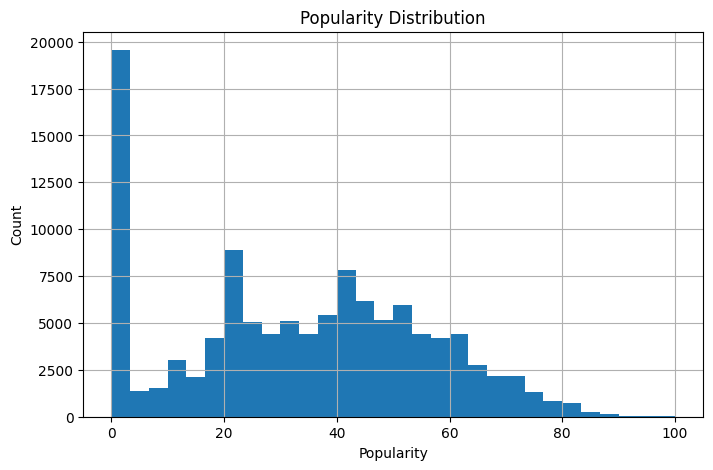

In [23]:
plt.figure(figsize=(8,5))

df['popularity'].hist(bins=30)

plt.xlabel('Popularity')
plt.ylabel('Count')
plt.title('Popularity Distribution')

plt.show()

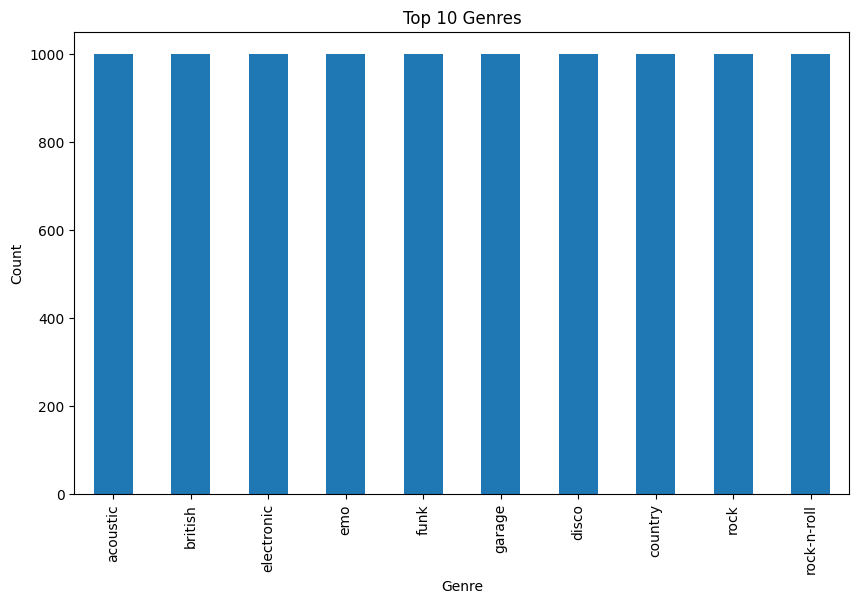

In [24]:
top_genres = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_genres.plot(kind='bar')

plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.show()

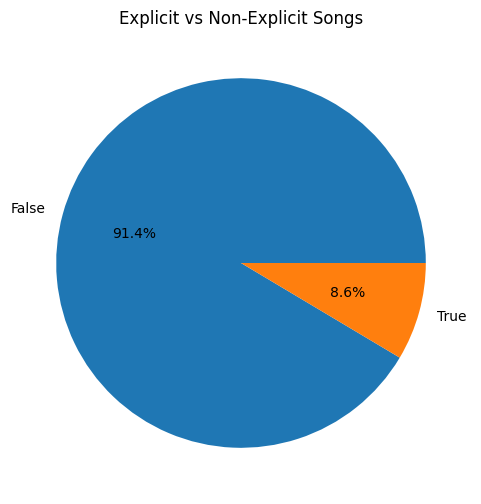

In [25]:
explicit_counts = df['explicit'].value_counts()

plt.figure(figsize=(6,6))

explicit_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Explicit vs Non-Explicit Songs')

plt.show()

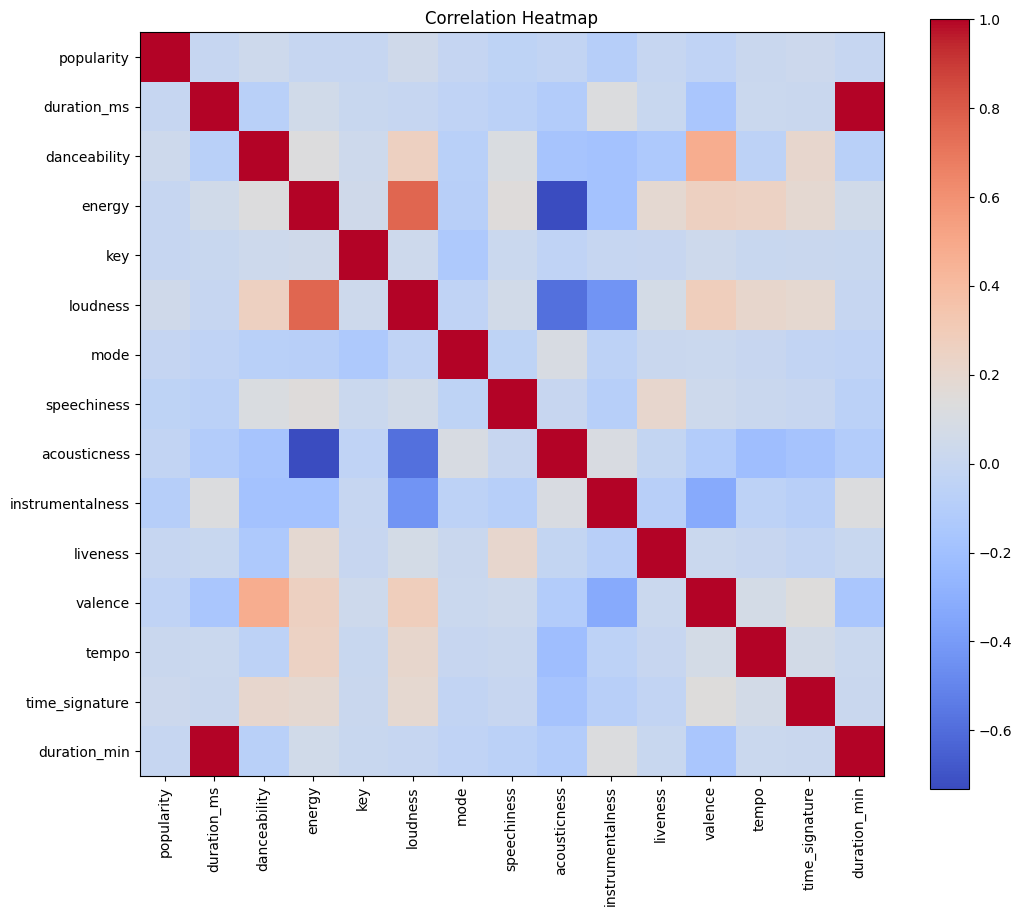

In [26]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Heatmap')

plt.show()

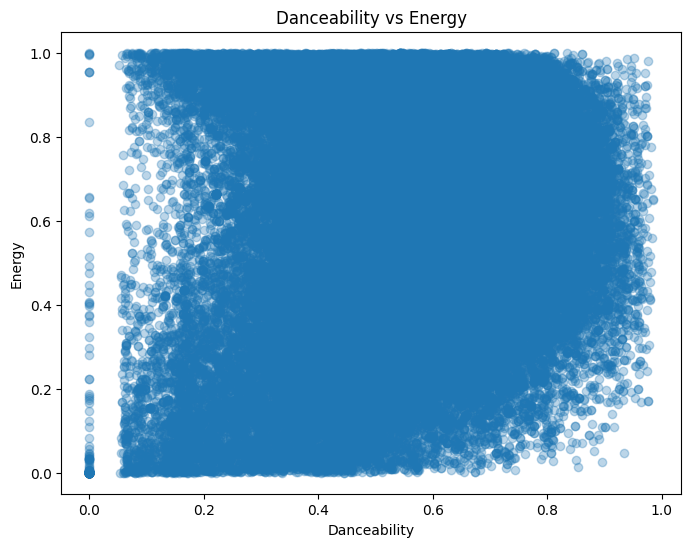

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['danceability'],
    df['energy'],
    alpha=0.3
)

plt.xlabel('Danceability')
plt.ylabel('Energy')

plt.title('Danceability vs Energy')

plt.show()

In [28]:
df[df['popularity'] > 95]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
20000,5IgjP7X4th6nMNDh4akUHb,Chris Brown,Indigo (Extended),Under The Influence,96,184613,True,0.733,0.690,9,...,0,0.0427,0.06350,0.000001,0.1050,0.310,116.992,4,dance,3.076883
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,...,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance,2.615717
20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,dance,2.920633
30003,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,edm,2.920633
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,...,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop,3.315617
67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latin,2.710617
67358,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,1,...,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,latin,2.976117
67359,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,5,...,0,0.2530,0.09930,0.000291,0.1260,0.187,106.672,4,latin,4.061933
67559,5Eax0qFko2dh7Rl2lYs3bx,Bad Bunny,Un Verano Sin Ti,Efecto,96,213061,False,0.801,0.475,7,...,0,0.0516,0.14100,0.000017,0.0639,0.234,98.047,4,latin,3.551017
68303,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latino,2.710617


In [29]:
df.corr(numeric_only=True)['popularity']\
.sort_values(ascending=False)

popularity          1.000000
loudness            0.047368
explicit            0.043938
danceability        0.034407
time_signature      0.030567
tempo               0.012187
energy             -0.002447
key                -0.004167
liveness           -0.005668
duration_ms        -0.007928
duration_min       -0.007928
mode               -0.015009
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
instrumentalness   -0.094718
Name: popularity, dtype: float64

In [30]:
features = [
    'danceability',
    'energy',
    'valence',
    'tempo',
    'acousticness',
    'loudness'
]

X = df[features]

In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [32]:
kmeans = KMeans(n_clusters=5)

df['cluster'] = kmeans.fit_predict(X_scaled)

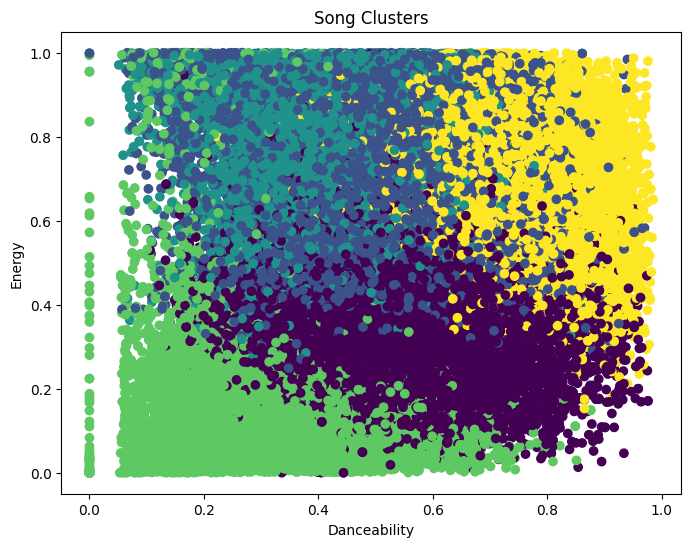

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['danceability'],
    df['energy'],
    c=df['cluster']
)

plt.xlabel('Danceability')
plt.ylabel('Energy')

plt.title('Song Clusters')

plt.show()

In [38]:
artist_stats = df.groupby('artists').agg({
    'popularity':'mean',
    'track_name':'count'
})

artist_stats.columns = ['avg_popularity','song_count']

artist_stats = artist_stats[
    artist_stats['song_count'] >= 1
]

artist_stats.sort_values(
    by='avg_popularity',
    ascending=False
).head(10)

,avg_popularity,song_count
artists,,
Sam Smith;Kim Petras,100.0,2
Bizarrap;Quevedo,99.0,1
Manuel Turizo,98.0,4
Bad Bunny;Chencho Corleone,97.0,4
Bad Bunny;Bomba Estéreo,94.5,4
Joji,94.0,1
Beyoncé,93.0,1
Harry Styles,92.0,3
Rema;Selena Gomez,92.0,1


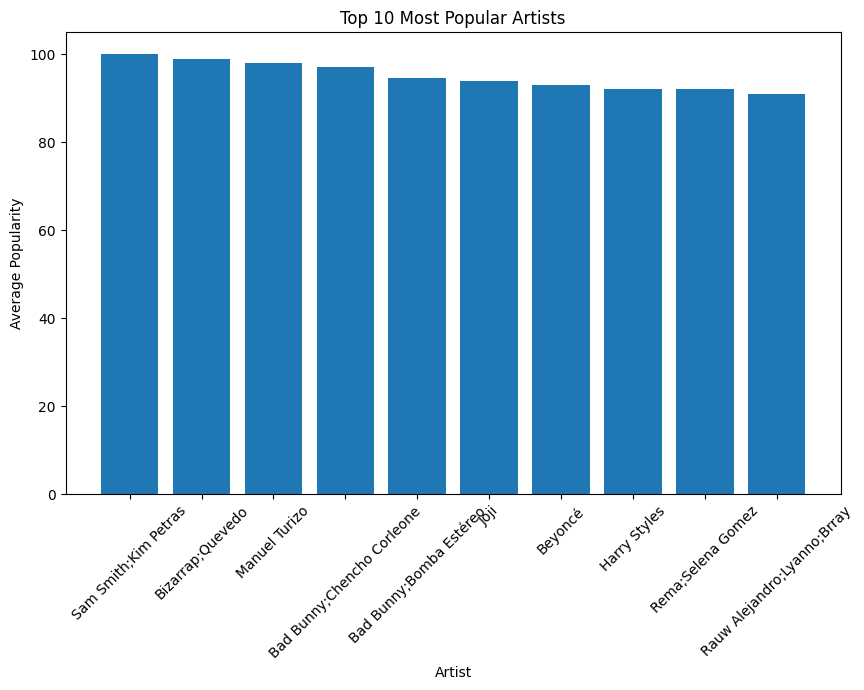

In [39]:
top_artists = artist_stats.sort_values(
    by='avg_popularity',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_artists.index,
    top_artists['avg_popularity']
)

plt.xticks(rotation=45)

plt.xlabel('Artist')
plt.ylabel('Average Popularity')

plt.title('Top 10 Most Popular Artists')

plt.show()

In [36]:
album_stats = df.groupby('album_name').agg({
    'popularity':'mean',
    'track_name':'count'
})

album_stats.columns = ['avg_popularity','song_count']

album_stats = album_stats[
    album_stats['song_count'] >= 3
]

album_stats.sort_values(
    by='avg_popularity',
    ascending=False
).head(10)

,avg_popularity,song_count
album_name,,
La Bachata,98.000000,4
"I Ain’t Worried (Music From The Motion Picture ""Top Gun: Maverick"")",96.000000,3
I'm Good (Blue),91.000000,4
L3tra,90.500000,4
Un Verano Sin Ti,90.142857,56
Ferrari,90.000000,4
Until I Found You,89.333333,3
One Kiss (with Dua Lipa),89.000000,5
La Llevo Al Cielo (Ft. Ñengo Flow),88.000000,3


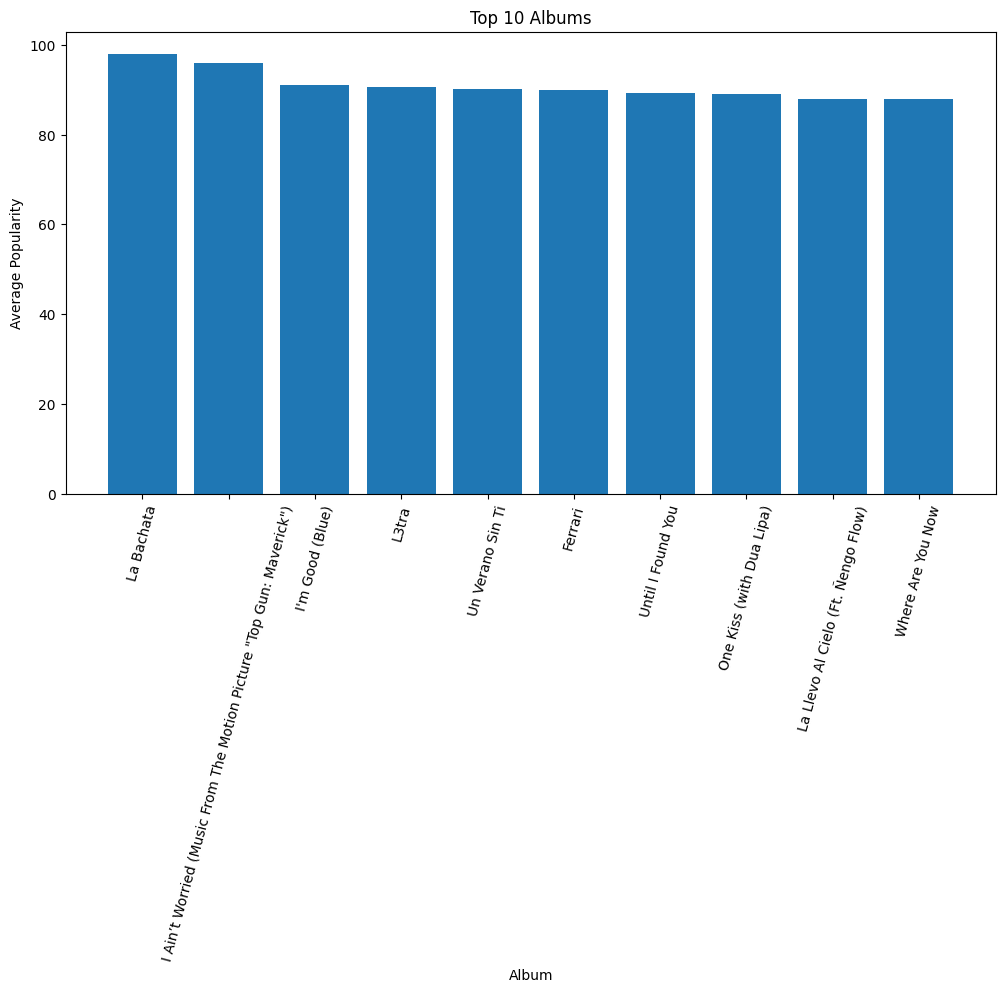

In [37]:
top_albums = album_stats.sort_values(
    by='avg_popularity',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_albums.index,
    top_albums['avg_popularity']
)

plt.xticks(rotation=75)

plt.xlabel('Album')
plt.ylabel('Average Popularity')

plt.title('Top 10 Albums')

plt.show()

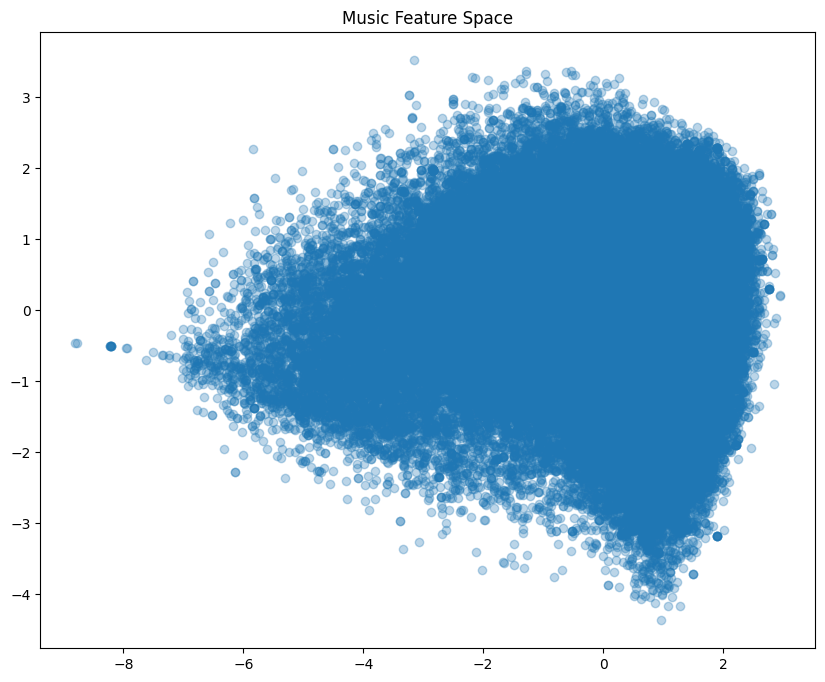

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    'danceability',
    'energy',
    'valence',
    'tempo',
    'acousticness',
    'loudness'
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.3
)

plt.title("Music Feature Space")
plt.show()

High energy + high valence
→ party songs

Low energy + low valence
→ emotional/depressing songs

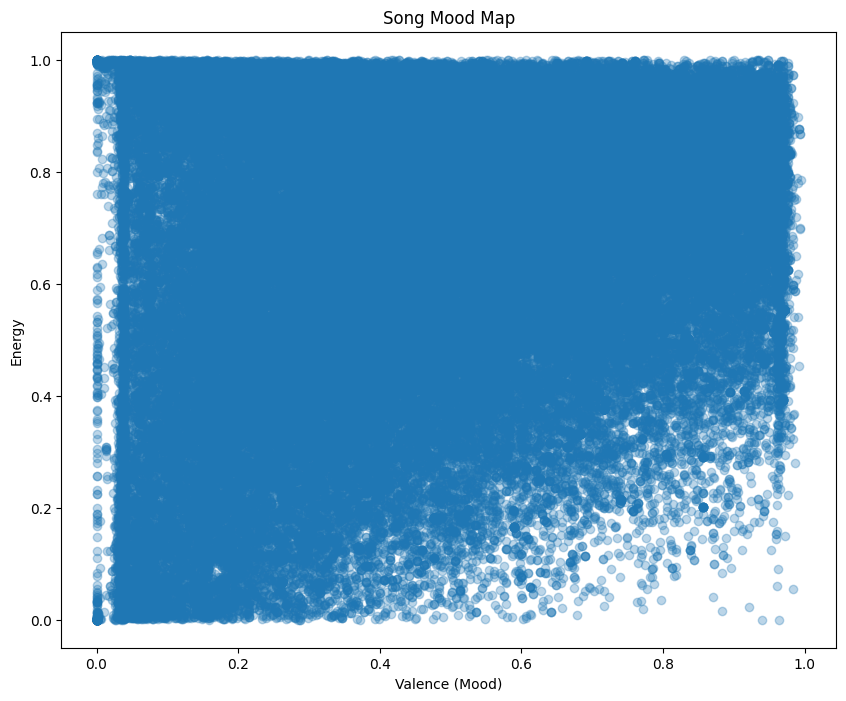

In [41]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['valence'],
    df['energy'],
    alpha=0.3
)

plt.xlabel('Valence (Mood)')
plt.ylabel('Energy')

plt.title('Song Mood Map')

plt.show()

In [43]:
corr = df.corr(numeric_only=True)['popularity']\
.sort_values(ascending=False)

print(corr)

popularity          1.000000
loudness            0.047368
explicit            0.043938
danceability        0.034407
time_signature      0.030567
tempo               0.012187
energy             -0.002447
key                -0.004167
liveness           -0.005668
duration_ms        -0.007928
duration_min       -0.007928
mode               -0.015009
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
cluster            -0.061969
instrumentalness   -0.094718
Name: popularity, dtype: float64


In [44]:
artist_var = df.groupby('artists')['popularity']\
.std()\
.sort_values(ascending=False)

artist_var.head(10)

artists
Justin Bieber;Ludacris        57.982756
Jordan Davis;Luke Bryan       56.568542
Cardi B;Bad Bunny;J Balvin    55.861436
Amaarae;Kali Uchis;Moliy      55.154329
Jordan Davis                  53.033009
Roy Woods;Drake               53.033009
Arz                           51.618795
Armani White                  51.097130
Selena Gomez;Gucci Mane       50.911688
When In Rome                  49.497475
Name: popularity, dtype: float64